# Figure S17. Mining CF metagenomes

In [1]:
%%bash
### Combine results from initial mining
cat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/prj*/*/*_cf/megahit/*_cf.contigs.fa.gz \
    > cf_metag_contigs.fa.gz

In [3]:
%%bash
### Combine results from locally sequenced samples
cat /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/results/uhvdb/assemble/lipuma_aim2/*/*/megahit/*.contigs.fa.gz \
    > lipuma_metag_contigs.fa.gz

In [ ]:
%%bash
### Mine CF metagenomes + UHBDB CF pathogens
mkdir -p uhvdb_cf_results
cd uhvdb_cf_results

nextflow run /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit \
    -profile uw_hyak \
    -w /gscratch/scrubbed/carsonjm/2026.03.26-uhvdb_cf \
    --input /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s16/uhvdb_cf_samplesheet.csv \
    --db_dir /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases \
    --checkv_db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/checkv_db/checkv_db_2026-03-26-2 \
    --output_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_s16/uhvdb_cf_results \
    --uhvdb_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2 \
    --hyak_partition="stf" \
    --hyak_queue="cpu-g2-mem2x" \
    --new_release_id="2026-04-03" \
    --run_classify=true \
    --genomad_split_size=50000 \
    --run_hqfilter=true \
    --run_hcfilter=true \
    --run_dereplicate=true \
    --run_anicluster=true \
    --run_aaicluster=true \
    --run_taxonomy=true \
    --vmr_url /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/VMR_MSL40.v2.20251013.xlsx \
    --vmr_dmnd /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/ictv/vmr_msl40_2_2025_10_13/VMR_MSL40.v2.20251013.dmnd \
    --run_function=true \
    --run_lifestyle=true \
    --run_crisprhost=true \
    --run_phist=true \
    --uhbdb_dir=/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/uhbdb \
    --run_update=true

In [4]:
import polars as pl

# motus_isolates = pl.read_csv('../uhbdb_creation/motusdb_isolates_samplesheet.tsv', separator='\t')
# motus_mags = pl.read_csv('../uhbdb_creation/motusdb_mag_samplesheet.tsv', separator='\t')

print("Number of Staphylococcus:", motus_isolates.filter(pl.col('genus') == 'Staphylococcus').height + motus_mags.filter(pl.col('genus') == 'Staphylococcus').height)
print("Number of Pseudomonas:", motus_isolates.filter(pl.col('genus') == 'Pseudomonas').height + motus_mags.filter(pl.col('genus') == 'Pseudomonas').height)
print("Number of Haemophilus:", motus_isolates.filter(pl.col('genus') == 'Haemophilus').height + motus_mags.filter(pl.col('genus') == 'Haemophilus').height)
print("Number of Stenotrophomonas:", motus_isolates.filter(pl.col('genus') == 'Stenotrophomonas').height + motus_mags.filter(pl.col('genus') == 'Stenotrophomonas').height)
print("Number of Burkholderia:", motus_isolates.filter(pl.col('genus') == 'Burkholderia').height + motus_mags.filter(pl.col('genus') == 'Burkholderia').height)
print("Number of Achromobacter:", motus_isolates.filter(pl.col('genus') == 'Achromobacter').height + motus_mags.filter(pl.col('genus') == 'Achromobacter').height)

Number of Staphylococcus: 37734
Number of Pseudomonas: 7684
Number of Haemophilus: 1311
Number of Stenotrophomonas: 985
Number of Burkholderia: 4559
Number of Achromobacter: 319


# Create final UHVDB metadata

In [ ]:
### Count unique sequences in UHVDB v4 vs v5
# !zgrep -c "^>" ../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_unique_reps.fna.gz

575596


In [ ]:
# !zgrep -c "^>" uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_unique_reps.fna.gz

617914


In [1]:
### Count number of unique sequences/hashes in v4 and v5
import polars as pl
v4_seqhash = pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_seqhasher.tsv.gz', separator='\t')
v5_seqhash = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_seqhasher.tsv.gz', separator='\t')
print("Total seqs in v4:", v4_seqhash.height)
print("Total seqs in v5:", v5_seqhash.height)
print("Unique seqs in v4:", v4_seqhash['original_id'].n_unique())
print("Unique seqs in v5:", v5_seqhash['original_id'].n_unique())
print("Unique hashes in v4:", v4_seqhash[['hash']].n_unique())
print("Unique hashes in v5:", v5_seqhash[['hash']].n_unique())
# Note: ~100 duplicated sequences (original_ids) in dataset
# Both of these were extracted when assigning UHVDB ids
# So there are ~100 duplicated sequences in UHVDB that have different uhvdb_ids
# True number of unique seqs in v4=575,497, v5=617,815

Total seqs in v4: 760806
Total seqs in v5: 816318
Unique seqs in v4: 760693
Unique seqs in v5: 816205
Unique hashes in v4: 575497
Unique hashes in v5: 617815


In [ ]:
### Count genomovar reps in UHVDB v4 vs v5
# !zgrep -c "^>" ../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_genomovars_reps.fna.gz

508382


In [ ]:
### Count genomovar reps in UHVDB v4 vs v5
# !zgrep -c "^>" uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_genomovars_reps.fna.gz

535799


In [2]:
### Count number of genomovar reps in v4 and v5
import polars as pl
v4_genomovars = pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_genomovars_info.tsv.gz', separator='\t')
v5_genomovars = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_genomovars_info.tsv.gz', separator='\t')
print("Total seqs in v4:", v4_genomovars.height)
print("Total seqs in v5:", v5_genomovars.height)
print("Unique seq ids in v4:", v4_genomovars['uhvdb_id'].n_unique())
print("Unique seq ids in v5:", v5_genomovars['uhvdb_id'].n_unique())
print("Genomovar reps in v4:", v4_genomovars['votu_rep'].n_unique())
print("Genomovar reps in v5:", v5_genomovars['votu_rep'].n_unique())
# Unique uhvdb_id counts match number of sequences (so all have unique uhvdb_ids even though ~100 seqs are duplicated)
# Genomovar reps in v4= 508,382, v5=535,799

Total seqs in v4: 576190
Total seqs in v5: 618508
Unique seq ids in v4: 575596
Unique seq ids in v5: 617914
Genomovar reps in v4: 508382
Genomovar reps in v5: 535799


In [ ]:
### Count species reps in v4 and v5
# !zgrep -c "^>" ../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_reps.fna.gz

199442


In [ ]:
# !zgrep -c "^>" uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_species_reps.fna.gz

206289


In [3]:
### Count number of species reps in v4 and v5
import polars as pl
v4_species = pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_info.tsv.gz', separator='\t')
v5_species = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_species_info.tsv.gz', separator='\t')
print("Total genomovar reps in v4:", v4_species.height)
print("Total genomovar reps in v5:", v5_species.height)
print("Unique genomovar reps in v4:", v4_species['uhvdb_id'].n_unique())
print("Unique genomovar reps in v5:", v5_species['uhvdb_id'].n_unique())
print("Species reps in v4:", v4_species['votu_rep'].n_unique())
print("Species reps in v5:", v5_species['votu_rep'].n_unique())
# At genomovar and species level, duplicated seqs no longer matter
# v4 species = 199,442; v5 species = 206,289

Total genomovar reps in v4: 508619
Total genomovar reps in v5: 536033
Unique genomovar reps in v4: 508382
Unique genomovar reps in v5: 535799
Species reps in v4: 199442
Species reps in v5: 206289


In [4]:
### Load classify report
import polars as pl

cf_uhvdb_classify = pl.read_csv('uhvdb_cf_results/2026-04-03_outputs/classify/new_mq_plus_classify.tsv.gz', separator='\t', ignore_errors=True)
cf_uhvdb_classify.height

608920

In [5]:
### Load outputs from final CF UHVDB mining
seqhasher_ids = set(
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_seqhasher.tsv.gz', separator='\t')
        ['original_id']
)
seqhasher_ids2 = set(
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_seqhasher.tsv.gz', separator='\t')
        .with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id")))
        ['original_id']
)
print("Number of unique UHVDB IDs:", len(seqhasher_ids))

Number of unique UHVDB IDs: 816205


In [6]:
### Filter CF viruses to only those in UHVDB
viruses_in_uhvdb = (
    cf_uhvdb_classify
        .filter(
            (pl.col('seq_name').is_in(seqhasher_ids)) |
            (pl.col('seq_name').is_in(seqhasher_ids2))
        )
)
viruses_in_uhvdb.height

55512

In [7]:
### Load data to identify motus mag body sites
motus_mag_meta = pl.read_csv('../uhbdb_creation/motusdb_mag_samplesheet.tsv', separator='\t')
motus_sample2environment = pl.read_csv('../host_genome_id/Supplementary_Table_4.tsv.gz', separator='\t', comment_prefix="!", columns=['#SAMPLE', 'BIOSAMPLE', 'STUDY', 'ENVIRONMENT'])


In [8]:
motus_mag2env = (
    motus_mag_meta[['genome', 'source_db', 'sample']]
        .join(motus_sample2environment[['BIOSAMPLE', 'ENVIRONMENT']], left_on='sample', right_on='BIOSAMPLE', how='left')
        .with_columns([
            pl.when(pl.col('ENVIRONMENT').str.contains('gut')).then(pl.lit('Gut'))
                .when(
                    (pl.col('ENVIRONMENT').str.contains('oral')) |
                    (pl.col('ENVIRONMENT').str.contains('respiratory')) |
                    (pl.col('ENVIRONMENT').str.contains('lung')) |
                    (pl.col('ENVIRONMENT').str.contains('nasopharyngeal'))
                    ).then(pl.lit('Airways'))
                .when(
                    (pl.col('ENVIRONMENT').str.contains('vaginal')) |
                    (pl.col('ENVIRONMENT').str.contains('reproductive'))
                    ).then(pl.lit('Urogenital'))
                .when((pl.col('ENVIRONMENT').str.contains('skin'))).then(pl.lit('Skin'))
                .otherwise(pl.lit('Other'))
                .alias('body_site')
        ])
)

viruses_in_uhvdb_final = (
    viruses_in_uhvdb
        .with_columns([
            pl.col('genome').str.split('-scaffold').list[0],
        ])
        .join(motus_mag2env[['genome', 'body_site']], on='genome', how='left')
        .with_columns([
            pl.when(pl.col('seq_name').str.contains('_GENO_')).then(pl.lit('MOTUS_DB'))
                .when(pl.col('seq_name').str.contains('_MAG_')).then(pl.lit('MOTUS_DB'))
                .otherwise(pl.lit('CF_METAG')).alias('source_db')
        ])
        .with_columns([
            pl.when(pl.col('source_db') == 'CF_METAG').then(pl.lit('Airways'))
                .when(pl.col('seq_name').str.contains('_GENO_')).then(pl.lit('Other'))
                .otherwise(pl.col('body_site'))
                .alias('body_site'),
            pl.when(pl.col('completeness_method') == 'DTR')
                .then(pl.lit('Complete'))
                .otherwise(pl.lit('High-quality'))
                .alias('checkv_quality'),
            pl.lit('Assembly').alias('db_type')
        ])
        [['seq_name', 'source_db', 'body_site', 'db_type', 'checkv_quality']]
        .unique('seq_name')
)

In [9]:
uhvdb_source_meta_v5 = pl.concat([
    pl.read_csv('../figure_1/uhvdb_final_metadata.tsv', separator='\t'),
    viruses_in_uhvdb_final
])

uhvdb_source_meta_v5.write_csv('uhvdb_v5_source_metadata.tsv', separator='\t')

In [10]:
# map from original id to species
import polars as pl

uhvdb_source_meta = pl.read_csv('uhvdb_v5_source_metadata.tsv', separator='\t')

seqhasher = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_seqhasher.tsv.gz', separator='\t').unique('original_id')
uhvdb_mapping =  pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_mapping.tsv.gz', separator='\t')

seqhash_reps = seqhasher.filter(pl.col('original_id').is_in(set(uhvdb_mapping['original_id']))).unique('original_id').rename({'original_id':'seqhash_rep'})
genomovar_info = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_genomovars_info.tsv.gz', separator='\t')
uhvdb_species_info = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_species_info.tsv.gz', separator='\t')
aaicluster = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_aaicluster.tsv.gz', separator='\t')

v5_cluster_metadata = (
    uhvdb_source_meta
        .join(seqhasher.unique('original_id'), left_on='seq_name', right_on='original_id', how='left')
        .join(seqhasher.with_columns(pl.col('original_id').str.extract(r"^(.*)\|provirus", group_index=1).fill_null(pl.col("original_id"))), left_on='seq_name', right_on='original_id', how='left')
        .with_columns(
            pl.when(pl.col('hash').is_not_null()).then(pl.col('hash')).otherwise(pl.col('hash_right')).alias('hash')
        )
        .drop(['hash_right'])
        .join(seqhash_reps, on='hash', how='left')
        .join(uhvdb_mapping.unique('original_id'), left_on='seqhash_rep', right_on='original_id', how='left')
        .rename({'new_id':'uhvdb_id'})
        .join(genomovar_info[['uhvdb_id', 'votu_rep', 'cluster_id']].unique('uhvdb_id'), on='uhvdb_id', how='left').rename({'votu_rep':'genomovar_rep', 'cluster_id':'genomovar_cluster_id'})
        .join(uhvdb_species_info[['uhvdb_id', 'votu_rep', 'cluster_id']].unique('uhvdb_id'), left_on='genomovar_rep', right_on='uhvdb_id', how='left')
        .rename({'cluster_id':'species_cluster_id', 'votu_rep':'species_rep'})
        .join(aaicluster.unique('uhvdb_id'), left_on='species_rep', right_on='uhvdb_id', how='left')
)
v5_cluster_metadata.write_csv('uhvdb_v5_cluster_metadata.tsv', separator='\t')
# should be 816,318 rows (this includes duplicate seq_names)
# there should be 816,205 unique seq_name
# 617,914 sequences in unique fasta (includes duplicates)
# 617,815 unique hashes in unique fasta

In [11]:
### Join classify data to cluster metadata
uhvdb_classify = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_classify.tsv.gz', separator='\t', ignore_errors=True)
        .unique('uhvdb_id')
        [[
            'uhvdb_id', 'topology', 'n_genes', 'genetic_code', 'virus_score', 'n_hallmarks', 'contig_length',
            'provirus', 'proviral_length', 'viral_genes', 'host_genes', 'completeness', 'completeness_method',
            'kmer_freq', 'Prediction', 'Score', 'uhvdb_virus_classification'
        ]]
)

v5_clus_class_metadata = (
    v5_cluster_metadata
        .join(uhvdb_classify, on='uhvdb_id', how='left')
)
v5_clus_class_metadata.height

816318

In [12]:
### Join hqfilter data to cluster metadata
uhvdb_hqfilter = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_hqfilter.tsv.gz', separator='\t', ignore_errors=True)
        .unique('uhvdb_id')
        [[
            'uhvdb_id', 'aai_expected_length', 'aai_completeness', 'aai_confidence', 'aai_error', 'aai_num_hits', 'aai_top_hit',
            'aai_id', 'aai_af'
        ]]
)

v5_clust_class_hq_meta = (
    v5_clus_class_metadata
        .join(uhvdb_hqfilter, on='uhvdb_id', how='left')
)
v5_clust_class_hq_meta.height

816318

In [14]:
### Join hcfilter data to cluster metadata
uhvdb_hcfilter = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_hcfilter.tsv.gz', separator='\t', ignore_errors=True)
        .unique('uhvdb_id')
)

v5_clust_class_hq_hc_meta = (
    v5_clust_class_hq_meta
        .join(uhvdb_hcfilter, on='uhvdb_id', how='left')
)
v5_clust_class_hq_hc_meta.height

816318

In [61]:
### Add taxonomy data to cluster metadata
taxonomy_df = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_ictv_taxonomy.tsv.gz', separator='\t')
        .sort('normscore', descending=True)
        .unique('uhvdb_id', maintain_order=True)
        [['uhvdb_id', 'taxonomy', 'ref', 'normscore', 'Class', 'Order', 'Family', 'Genus', 'Species']]
        .rename({"taxonomy":'genomad_taxonomy', 'ref':'ictv_ref', 'normscore':'ictv_proteinsimilarity', 'Class':'ictv_class', 'Order':'ictv_order', 'Family':'ictv_family', 'Genus':'ictv_genus', 'Species':'ictv_species'})
)
taxonomy_df

v5_clust_class_hq_hc_tax_meta = (
    v5_clust_class_hq_hc_meta
        .join(taxonomy_df, left_on='genomovar_rep', right_on='uhvdb_id', how='left')
)
v5_clust_class_hq_hc_tax_meta.filter(pl.col('ictv_class').is_not_null()).height

816318

In [54]:
### Add crispr data to cluster metadata
crispr_df = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_crisprhost.tsv.gz', separator='\t')
        .unique(['uhvdb_id', 'rank'])
        .group_by('uhvdb_id')
        .agg([
            pl.col('top_taxonomy').filter(pl.col('rank') == 'species').first().alias('crispr_gtdb_r220_species'),
            pl.col('total_connections').filter(pl.col('rank') == 'species').first().alias('crispr_species_connections'),
            pl.col('agreement').filter(pl.col('rank') == 'species').first().alias('crispr_species_agreement'),

            pl.col('top_taxonomy').filter(pl.col('rank') == 'genus').first().alias('crispr_gtdb_r220_genus'),
            pl.col('total_connections').filter(pl.col('rank') == 'genus').first().alias('crispr_genus_connections'),
            pl.col('agreement').filter(pl.col('rank') == 'genus').first().alias('crispr_genus_agreement'),

            pl.col('top_taxonomy').filter(pl.col('rank') == 'family').first().alias('crispr_gtdb_r220_family'),
            pl.col('total_connections').filter(pl.col('rank') == 'family').first().alias('crispr_family_connections'),
            pl.col('agreement').filter(pl.col('rank') == 'family').first().alias('crispr_family_agreement'),
        ])
)
crispr_df

v5_clust_class_hq_hc_tax_crispr_meta = (
    v5_clust_class_hq_hc_tax_meta
        .join(crispr_df, left_on='genomovar_rep', right_on='uhvdb_id', how='left')
)
v5_clust_class_hq_hc_tax_crispr_meta.filter(pl.col('crispr_gtdb_r220_family').is_not_null()).height

679131

In [ ]:
# %%bash
# ### Create phist output
# for file in uhvdb_cf_results/2026-04-03_outputs/phist/chunk_*/*.csv.gz; do
#     zcat $file | head -n 1 > uhvdb_v5_test_phist.csv
#     break
# done

# ### Combine files
# for file in uhvdb_cf_results/2026-04-03_outputs/phist/chunk_*/*.csv.gz; do
#     if [ $(zcat $file | wc -l) -gt 2 ]; then
#         zcat $file | tail -n +3 >> uhvdb_v5_test_phist.csv
#     else
#         echo "File \$file has only header line or is empty; skipping content append."
#     fi
# done

# ### Identify consensus host
# uhvdb_phisthost.py \
#     --uhbdb_dir /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/uhbdb \
#     --phist_csv uhvdb_v5_test_phist.csv \
#     --output uhvdb_v5_test

# ### Compress
# gzip uhvdb_v5_test_phisthost.tsv uhvdb_v5_test_phist.tsv

In [55]:
### Add phist data to cluster metadata
phist_df = (
    pl.concat([
        pl.read_csv('uhvdb_v5_test_phisthost.tsv.gz', separator='\t'),
        pl.read_csv('../figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_phisthost.tsv.gz', separator='\t')
    ])
        .unique(['uhvdb_id', 'rank'])
        .group_by('uhvdb_id')
        .agg([
            pl.col('consensus_taxonomy').filter(pl.col('rank') == 'species').first().str.replace('s__','').alias('phist_gtdb_r226_species'),
            pl.col('total_connections').filter(pl.col('rank') == 'species').first().alias('phist_species_connections'),
            pl.col('agreement').filter(pl.col('rank') == 'species').first().alias('phist_species_agreement'),

            pl.col('consensus_taxonomy').filter(pl.col('rank') == 'genus').first().str.replace('g__','').alias('phist_gtdb_r226_genus'),
            pl.col('total_connections').filter(pl.col('rank') == 'genus').first().alias('phist_genus_connections'),
            pl.col('agreement').filter(pl.col('rank') == 'genus').first().alias('phist_genus_agreement'),

            pl.col('consensus_taxonomy').filter(pl.col('rank') == 'family').first().str.replace('f__','').alias('phist_gtdb_r226_family'),
            pl.col('total_connections').filter(pl.col('rank') == 'family').first().alias('phist_family_connections'),
            pl.col('agreement').filter(pl.col('rank') == 'family').first().alias('phist_family_agreement'),
        ])
)
phist_df

v5_clust_class_hq_hc_tax_crispr_phist_meta = (
    v5_clust_class_hq_hc_tax_crispr_meta
        .join(phist_df, left_on='genomovar_rep', right_on='uhvdb_id', how='left')
)
v5_clust_class_hq_hc_tax_crispr_phist_meta.filter(pl.col('phist_gtdb_r226_family').is_not_null()).height

508438

In [56]:
### create finalized host predictions
v5_clust_class_hq_hc_tax_crispr_phist_meta2 = (
    v5_clust_class_hq_hc_tax_crispr_phist_meta
        .fill_null(0)
        .with_columns([
            pl.when((pl.col('phist_species_connections') >= pl.col('crispr_species_connections')) & (pl.col('phist_species_connections') > 0)).then(pl.col('phist_gtdb_r226_species'))
                .when(pl.col('phist_species_connections') < pl.col('crispr_species_connections')).then(pl.col('crispr_gtdb_r220_species'))
                .when((pl.col('phist_genus_connections') >= pl.col('crispr_genus_connections')) & (pl.col('phist_genus_connections') > 0)).then(pl.col('phist_gtdb_r226_genus'))
                .when(pl.col('phist_genus_connections') < pl.col('crispr_genus_connections')).then(pl.col('crispr_gtdb_r220_genus'))
                .when((pl.col('phist_family_connections') >= pl.col('crispr_family_connections')) & (pl.col('phist_family_connections') > 0)).then(pl.col('phist_gtdb_r226_family'))
                .when(pl.col('phist_family_connections') < pl.col('crispr_family_connections')).then(pl.col('crispr_gtdb_r220_family'))
                .otherwise(pl.lit(None))
                .alias('top_host_taxonomy'),
        ])
)

In [57]:
# convert host predictions to full lineage using taxopy
# import taxopy
# import glob 

# url_r226 = "https://github.com/shenwei356/gtdb-taxdump/releases/download/v0.6.0/gtdb-taxdump-R226.tar.gz"
# taxdb_r226 = taxopy.TaxDb(
#     taxdump_url=url_r226
# )

# # 1) list all unique species names
# unique_final_species = (
#     v5_clust_class_hq_hc_tax_crispr_phist_meta2
#         .select('top_host_taxonomy')
#         .drop_nulls()
#         .unique()
#         .to_series()
#         .to_list()
# )

# # rank order + prefixes
# rank_prefix = [
#     ('superkingdom', 's__'),
#     ('phylum', 'p__'),
#     ('class', 'c__'),
#     ('order', 'o__'),
#     ('family', 'f__'),
#     ('genus', 'g__'),
#     ('species', 's__'),
# ]

# # 2) build mapping: species -> prefixed lineage
# species_to_lineage = {}
# for species in unique_final_species:
#     taxids = taxopy.taxid_from_name(species, taxdb_r226)
#     if not taxids:
#         continue

#     taxid = taxids[0]
#     taxon = taxopy.Taxon(taxid, taxdb_r226)
#     rank_name = taxon.rank_name_dictionary

#     lineage_parts = [
#         f"{prefix}{rank_name[rank]}"
#         for rank, prefix in rank_prefix
#         if rank in rank_name and rank_name[rank] is not None
#     ]
#     lineage = ';'.join(lineage_parts)  # no spaces between ranks
#     species_to_lineage[species] = lineage

# 3) replace final_species with lineage using polars replace
v5_clust_class_hq_hc_tax_crispr_phist_meta3 = (
    v5_clust_class_hq_hc_tax_crispr_phist_meta2
        .with_columns([
            pl.col('top_host_taxonomy').replace(species_to_lineage).str.replace(r'^s__', 'd__').alias('final_lineage'),
        ])
)

In [58]:
### Add lifestyle data to cluster metadata
# load v4 lifestyle
v4_lifestyle = pl.read_csv('../figure_3/uhvdb_v4_lifestyle.tsv', separator='\t')
v4_lifestyle

## load bacphlip outputs
new_bacphlip = pl.read_csv('uhvdb_cf_results/2026-04-03_outputs/lifestyle/new_genomovars_bacphlip.tsv.gz', separator='\t')
print(new_bacphlip.height)

## load classify outputs
classify_df = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_classify.tsv.gz', separator='\t', columns=['uhvdb_id', 'topology', 'provirus'])
        .filter(pl.col('uhvdb_id').is_in(set(new_bacphlip[''])))
        .unique('uhvdb_id')
)
classify_df.height

27720


27720

In [33]:
## load uhvdb protein outputs
prothash_df = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_proteinhash.tsv.gz', separator='\t')
        .unique('protein_id')
        .with_columns([
            pl.col('protein_id').str.replace(r"_[^_]*$", "").alias('genomovar_rep')
        ])
        .filter(pl.col('genomovar_rep').is_in(set(new_bacphlip[''])))
)
prothash_df.unique('genomovar_rep').height

27720

In [35]:
### get pharokka, phold, and empathi results for missing seqs
new_prothashes = set(prothash_df['hash'])
combined_pharokka = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_pharokka.tsv.gz', separator='\t', columns=['ID', 'annot', 'category']).filter(pl.col('ID').is_in(new_prothashes))
combined_phold = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_phold.tsv.gz', separator='\t', columns=['cds_id', 'function', 'product']).filter(pl.col('cds_id').is_in(new_prothashes))
combined_empathi = pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_empathi.csv.gz', columns=['', 'Annotation']).filter(pl.col('').is_in(new_prothashes))

In [39]:
# load classify tsv
classify = classify_df[['uhvdb_id', 'topology', 'provirus']]

# load bacphlip tsv
bacphlip = new_bacphlip.rename({'': 'uhvdb_id', 'Virulent':'virulent', 'Temperate':'temperate'})

# load protein2hash tsv
protein2hash = (
    prothash_df
        .rename({'hash': 'cds_id'})
        .with_columns([pl.col('protein_id').str.replace(r"_[^_]*$", "").alias('uhvdb_id')])
)

# load pharokka tsv
pharokka = (
   combined_pharokka
        .rename({'ID':'cds_id'})
        .join(protein2hash, on='cds_id', how='left')
)

# load phold tsv
phold = (
    combined_phold
        .rename({'product':'annot', 'function':'category'})
        [['cds_id', 'annot', 'category']]
        .join(protein2hash, on='cds_id', how='left')
)

# identify integrase/recombinases in pharokka and phold annotations
phrogs = (
    pl.concat([pharokka, phold])
)

phrog_integrases = (
    phrogs
        .filter(pl.col('annot').str.contains(r'integrase|recombinase'))
        .group_by('uhvdb_id')
        .len()
        .rename({'len': 'phrog_integrases'})
)

phrog_integration_excision = (
    phrogs
        .filter(pl.col('category').str.contains('integration and excision'))
        .group_by('uhvdb_id')
        .len()
        .rename({'len': 'phrog_integration_excision'})
)

# load empathi csv
empathi = (
    combined_empathi
        .filter(pl.col('Annotation').str.contains('integration'))
        .rename({'': 'cds_id'})
        .join(protein2hash, on='cds_id', how='left')
        .group_by('uhvdb_id')
        .len()
        .rename({'len': 'empathi_integration'})
)

# combine all results
new_lifestyles = (
    classify
        .join(bacphlip, on='uhvdb_id', how='inner')
        .join(phrog_integrases, on='uhvdb_id', how='left')
        .join(phrog_integration_excision, on='uhvdb_id', how='left')
        .join(empathi, on='uhvdb_id', how='left')
)
new_lifestyles.unique('uhvdb_id').height

27720

In [59]:
### Combine v5 and v5 lifestyle
combined_lifestyle = pl.concat([
    v4_lifestyle, new_lifestyles
], how='vertical_relaxed')
combined_lifestyle.unique('uhvdb_id')

# Genomovar reps in v5: 535799

v5_clust_class_hq_hc_tax_crispr_phist_life_meta = (
    v5_clust_class_hq_hc_tax_crispr_phist_meta3
        .join(combined_lifestyle, left_on='genomovar_rep', right_on='uhvdb_id', how='left')
)
v5_clust_class_hq_hc_tax_crispr_phist_life_meta.filter(pl.col('temperate').is_not_null()).height

816318

In [63]:
v5_clust_class_hq_hc_tax_crispr_phist_life_meta.write_csv('uhvdb_v5_metadata_through_lifestyle.tsv', separator='\t')

In [ ]:
### Create function metadata
# for each genomovar rep
# 1. num proteins
# 2. num uniprot/ips
# 3. card hits
# 4. vfdb hits
# mcp?
# terL?
# portal?
# 5. head hits
# 6. tail hits
# 8. lysis hits

In [1]:
## load uhvdb protein outputs
import polars as pl

v5_prothash_df = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_proteinhash.tsv.gz', separator='\t')
        .unique('protein_id')
        .with_columns([
            pl.col('protein_id').str.replace(r"_[^_]*$", "").alias('genomovar_rep')
        ])
)
v5_prothash_df.unique('genomovar_rep').height

546634

In [2]:
v5_bakta = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_bakta.tsv.gz', separator='\t', columns=['Locus Tag', 'Accession'], new_columns=['hash', 'bakta_acc'], null_values=['-'], skip_rows=5, ignore_errors=True)
)

In [3]:
v5_foldseek = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_foldseek.tsv.gz', separator='\t', has_header=False, columns=['column_1', 'column_2'], new_columns=['hash', 'foldseek_acc'])
)

In [8]:
v5_ips = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_interproscan.tsv.gz', separator='\t', ignore_errors=True, has_header=False, columns=['column_1', 'column_5'], new_columns=['hash', 'ips_id'])
    .group_by('hash')
    .agg(pl.col('ips_id').cast(pl.String).str.join(",").alias('ips_id'))
)

In [9]:
v5_card = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_card.tsv.gz', separator='\t', ignore_errors=True, has_header=False, columns=['column_1', 'column_2'], new_columns=['hash', 'card_acc'])
)

In [10]:
v5_vfdb = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_vfdb.tsv.gz', separator='\t', ignore_errors=True, has_header=False, columns=['column_1', 'column_2'], new_columns=['hash', 'vfdb_acc'])
)

In [11]:
v5_pharokka = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_pharokka.tsv.gz', separator='\t', ignore_errors=True, columns=['ID', 'annot', 'category'], new_columns=['hash', 'pharokka_annot', 'pharokka_category'])
        .filter(pl.col('pharokka_annot') != 'hypothetical protein')
)

In [12]:
v5_phold = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_phold.tsv.gz', separator='\t', ignore_errors=True, columns=['cds_id', 'function', 'product'], new_columns=['hash', 'phold_category', 'phold_annot'])
        .filter(pl.col('phold_category') != 'unknown function')
)

In [13]:
v5_empathi = (
    pl.read_csv('uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_empathi.csv.gz', ignore_errors=True, columns=['', 'Annotation'], new_columns=['hash', 'empathi_annot'])
)

In [14]:
v5_prot_annot_df = (
    v5_prothash_df
        .join(v5_bakta, on='hash', how='left')
        .join(v5_foldseek, on='hash', how='left')
        .join(v5_ips, on='hash', how='left')
        .join(v5_card, on='hash', how='left')
        .join(v5_vfdb, on='hash', how='left')
        .join(v5_pharokka, on='hash', how='left')
        .join(v5_phold, on='hash', how='left')
        .join(v5_empathi, on='hash', how='left')
)

del v5_prothash_df, v5_bakta, v5_foldseek, v5_ips, v5_card, v5_vfdb, v5_pharokka, v5_phold, v5_empathi

In [15]:
v5_prot_annot_df.write_csv('uhvdb_v5_protein_annotations.tsv', separator='\t')

In [17]:
import polars as pl

v5_prot_annot_df = pl.read_csv('uhvdb_v5_protein_annotations.tsv', separator='\t')
v5_clust_class_hq_hc_tax_crispr_phist_life_meta = pl.read_csv('uhvdb_v5_metadata_through_lifestyle.tsv', separator='\t')

v5_prot_annot_by_genomovar = (
    v5_prot_annot_df
        .group_by('genomovar_rep').agg([
            pl.count('hash').alias('num_proteins'),
            ((pl.col('bakta_acc').is_not_null()) | (pl.col('foldseek_acc').is_not_null()) | (pl.col('ips_id').is_not_null())).sum().alias('num_uniprot_ips'),
            (pl.col('card_acc').is_not_null()).sum().alias('card_hits'),
            (pl.col('vfdb_acc').is_not_null()).sum().alias('vfdb_hits'),
            ((pl.col('pharokka_category').str.contains('tail')) | (pl.col('phold_category').str.contains('tail')) | (pl.col('empathi_annot').str.contains('tail'))).sum().alias('num_tail'),
            ((pl.col('pharokka_category').str.contains('head')) | (pl.col('phold_category').str.contains('head')) | (pl.col('empathi_annot').str.contains('capsid'))).sum().alias('num_capsid'),
            ((pl.col('pharokka_category').str.contains('lysis')) | (pl.col('phold_category').str.contains('lysis')) | (pl.col('empathi_annot').str.contains('lysis'))).sum().alias('num_lysis'),
            (((pl.col('pharokka_annot') == 'major head protein').sum() == 1) | ((pl.col('phold_category') == 'major head protein').sum() == 1) | ((pl.col('empathi_annot') == 'pvp|capsid|major_capsid').sum() == 1)).sum().alias('num_mcp'),
            (((pl.col('pharokka_annot') == 'terminase large subunit').sum() == 1) | ((pl.col('phold_category') == 'terminase large subunit').sum() == 1) | ((pl.col('empathi_annot') == 'DNA-associated|terminase|packaging_assembly').sum() == 1)).sum().alias('num_terl'),
            (((pl.col('pharokka_annot') == 'portal protein').sum() == 1) | ((pl.col('phold_category') == 'portal protein').sum() == 1) | ((pl.col('empathi_annot') == 'pvp|portal').sum() == 1)).sum().alias('num_portal'),
        ])
        .filter(pl.col('genomovar_rep').is_in(set(v5_clust_class_hq_hc_tax_crispr_phist_life_meta['genomovar_rep'])))
        .unique('genomovar_rep')
)

In [30]:
v5_clust_class_hq_hc_tax_crispr_phist_life_func_meta = (
    v5_clust_class_hq_hc_tax_crispr_phist_life_meta
        .join(v5_prot_annot_by_genomovar, on='genomovar_rep', how='left')
)
v5_clust_class_hq_hc_tax_crispr_phist_life_func_meta.height

816318

In [33]:
v5_clust_class_hq_hc_tax_crispr_phist_life_func_meta2 = (
    v5_clust_class_hq_hc_tax_crispr_phist_life_func_meta
        .drop('topology_right', 'provirus_right')
        .rename({'top_host_taxonomy':'final_host_pred', 'final_lineage':'host_lineage', 'card_hits':'num_card', 'vfdb_hits':'num_vfdb', 'num_mcp':'mcp_hallmark', 'num_terl':'terl_hallmark', 'num_portal':'portal_hallmark'})
)

v5_clust_class_hq_hc_tax_crispr_phist_life_func_meta2.write_csv('uhvdb_v5_final_metadata.tsv', separator='\t')

In [13]:
### Create sylph metadata file
import polars as pl
uhvdb_metadata = pl.read_csv('uhvdb_v5_final_metadata.tsv.gz', separator='\t')

uhvdb_metadata_tax = (
    uhvdb_metadata
        .with_columns([
            (
                pl.col('genomad_taxonomy').str.replace(r'viricetes;.*', 'viricetes;;')
                 + pl.lit('vFAM-') + pl.col('family_cluster_id').cast(pl.String)
                + pl.lit(';vSUBFAM-') + pl.col('subfamily_cluster_id').cast(pl.String)
                + pl.lit(';vGENUS-') + pl.col('genus_cluster_id').cast(pl.String)
                + pl.lit(';vSUBGENUS-') + pl.col('subgenus_cluster_id').cast(pl.String)
                + pl.lit(';vSPECIES-') + pl.col('species_cluster_id').cast(pl.String)
            )
            .alias('final_virus_taxonomy')
        ])
)

### aggregate to species level
uhvdb_metadata_species = (
    uhvdb_metadata_tax
        .group_by(['species_rep'])
        .agg([
            # identify most prevalent lifestyle
            pl.col('final_virus_taxonomy').value_counts(sort=True).first().struct.field('final_virus_taxonomy').alias('final_virus_taxonomy'),
            pl.col('host_lineage').value_counts(sort=True).first().struct.field('host_lineage').alias('host_lineage'),
            # identify counts of most prev lifestyle
            pl.col('final_virus_taxonomy').value_counts(sort=True).first().struct.field('count').alias('virus_taxonomy_count'),
            pl.col('host_lineage').value_counts(sort=True).first().struct.field('count').alias('host_lineage_count'),
            # identify total counts of all lifestyles
            pl.len().alias('total_species_count')
        ])
        .with_columns([
            (pl.col('virus_taxonomy_count')/pl.col('total_species_count')).alias('virus_taxonomy_proportion'),
            (pl.col('host_lineage_count')/pl.col('total_species_count')).alias('host_lineage_proportion'),
        ])
)
uhvdb_metadata_species[['species_rep', 'final_virus_taxonomy', 'host_lineage']]
uhvdb_metadata_species[['species_rep', 'final_virus_taxonomy', 'host_lineage']].write_csv('uhvdb_v5_sylph_metadata.tsv', separator='\t', include_header=False)

# UHVDB CF virus characteristics

In [12]:
import polars as pl

uhvdb_metadata = pl.read_csv('uhvdb_v5_final_metadata.tsv.gz', separator='\t')

In [14]:
cf_metadata = (
    uhvdb_metadata
        .filter(pl.col('source_db').is_in(['CF_METAG', 'MOTUS_DB']))
        .unique('hash')
)
cf_metadata.head(1)

seq_name,source_db,body_site,db_type,checkv_quality,hash,seqhash_rep,uhvdb_id,genomovar_rep,genomovar_cluster_id,species_rep,species_cluster_id,family_cluster_id,subfamily_cluster_id,genus_cluster_id,subgenus_cluster_id,topology,n_genes,genetic_code,virus_score,n_hallmarks,contig_length,provirus,proviral_length,viral_genes,host_genes,completeness,completeness_method,kmer_freq,Prediction,Score,uhvdb_virus_classification,aai_expected_length,aai_completeness,aai_confidence,aai_error,aai_num_hits,…,ictv_genus,ictv_species,crispr_gtdb_r220_species,crispr_species_connections,crispr_species_agreement,crispr_gtdb_r220_genus,crispr_genus_connections,crispr_genus_agreement,crispr_gtdb_r220_family,crispr_family_connections,crispr_family_agreement,phist_gtdb_r226_species,phist_species_connections,phist_species_agreement,phist_gtdb_r226_genus,phist_genus_connections,phist_genus_agreement,phist_gtdb_r226_family,phist_family_connections,phist_family_agreement,final_host_pred,host_lineage,virulent,temperate,phrog_integrases,phrog_integration_excision,empathi_integration,num_proteins,num_uniprot_ips,num_card,num_vfdb,num_tail,num_capsid,num_lysis,mcp_hallmark,terl_hallmark,portal_hallmark
str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,i64,i64,str,i64,i64,f64,i64,i64,str,str,i64,i64,f64,str,f64,str,f64,str,f64,f64,str,f64,i64,…,str,str,str,i64,f64,str,i64,f64,str,i64,f64,str,i64,f64,str,i64,f64,str,i64,f64,str,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""SAMN33100598_SRR23346060_cf_k2…","""CF_METAG""","""Airways""","""Assembly""","""High-quality""","""dbdfaa377ea2293a50a31b30efca4b…","""SAMN33100598_SRR23346060_cf_k2…","""UHVDB-577476""","""UHVDB-577476""",41784,"""UHVDB-577476""",58412,152,203,179,13811,"""No terminal repeats""",71,11,0.9998,18,42648,"""No""","""NA""",53,0,98.89,"""AAI-based (high-confidence)""",1.0,"""Virus""",110.24,"""confident""",42975.257561,99.238498,"""high""",2.006781,36,…,"""Hinxtonvirus""","""Hinxtonvirus K13""",null,0,0.0,"""Streptococcus""",66,0.984848,"""Streptococcaceae""",66,0.984848,null,0,0.0,"""Streptococcus""",9,1.0,"""Streptococcaceae""",9,1.0,"""Streptococcus""","""d__Bacteria;p__Bacillota;c__Ba…",0.0125,0.9875,1,2,5,70,70,0,1,21,7,3,1,1,1


/tmp/ipykernel_50336/394926440.py:37: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values='proportion', index='source_db', columns='ictv_class')


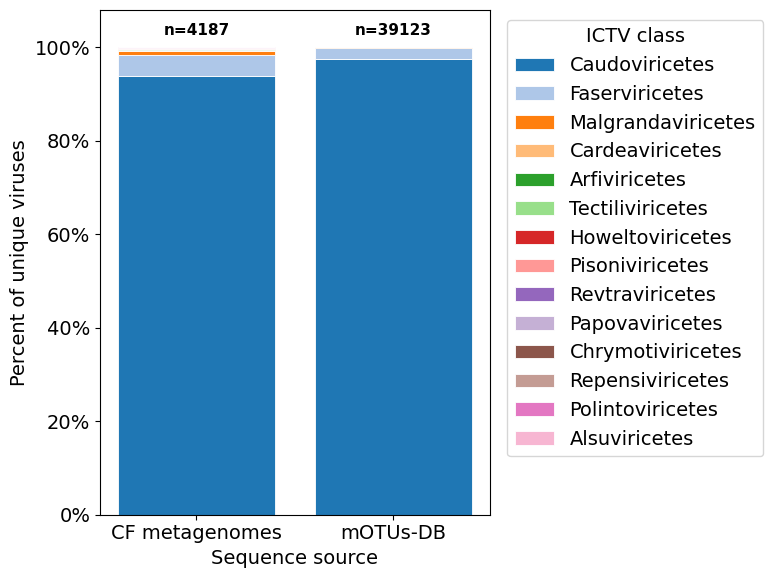

In [48]:
### Barchart of ICTV Class
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plt.rcParams.update({'font.size': 14})

ictv_class_props = (
    cf_metadata
        .with_columns(
            pl.when(pl.col('ictv_class').is_null() | (pl.col('ictv_class') == ''))
                .then(pl.lit('Unclassified'))
                .otherwise(pl.col('ictv_class'))
                .alias('ictv_class'),
            pl.col('source_db').str.replace('CF_METAG', 'CF metagenomes').str.replace('MOTUS_DB', 'mOTUs-DB')
        )
        .group_by(['source_db', 'ictv_class'])
        .agg(pl.len().alias('n_unique_viruses'))
        .with_columns(
            pl.col('n_unique_viruses').sum().over('source_db').alias('source_db_total')
        )
        .with_columns(
            (pl.col('n_unique_viruses') / pl.col('source_db_total')).alias('proportion')
        )
)

class_order = (
    ictv_class_props
        .group_by('ictv_class')
        .agg(pl.col('n_unique_viruses').sum().alias('n'))
        .sort('n', descending=True)
        ['ictv_class']
        .to_list()
)

plot_df = (
    ictv_class_props
        .select(['source_db', 'ictv_class', 'proportion'])
        .pivot(values='proportion', index='source_db', columns='ictv_class')
        .fill_null(0)
        .sort('source_db')
)
source_db_order = plot_df['source_db'].to_list()
available_classes = [c for c in class_order if c in plot_df.columns]

# Get total counts per source_db
source_db_totals = (
    ictv_class_props
        .select('source_db', 'source_db_total')
        .unique('source_db')
        .sort('source_db')
)
totals = source_db_totals['source_db_total'].to_list()

fig, ax = plt.subplots(figsize=(8, 6))
bottom = [0.0] * len(source_db_order)
colors = plt.get_cmap('tab20').colors

for i, ictv_class in enumerate(available_classes):
    values = plot_df[ictv_class].to_list()
    ax.bar(
        source_db_order,
        values,
        bottom=bottom,
        label=ictv_class,
        color=colors[i % len(colors)],
        edgecolor='white',
        linewidth=0.6,
    )
    bottom = [b + v for b, v in zip(bottom, values)]

# Add count labels above each source database
max_height = max(bottom)
for i, total in enumerate(totals):
    ax.text(i, max_height * 1.02, f'n={total}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Percent of unique viruses')
ax.set_xlabel('Sequence source')
ax.set_ylim(0, max_height * 1.08)
ax.legend(title='ICTV class', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

/tmp/ipykernel_50336/2246118630.py:79: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values='proportion', index='source_db', columns='host_lineage')


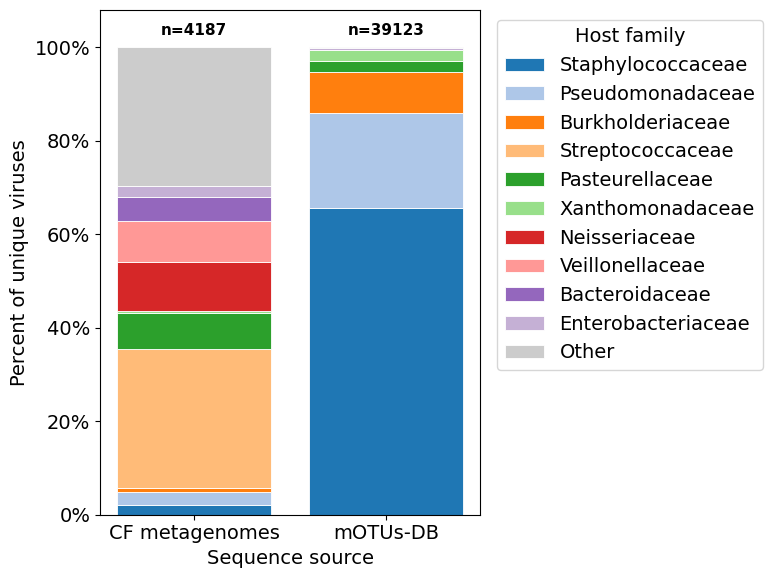

In [53]:
### Bar chart of predicted hosts
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plt.rcParams.update({'font.size': 14})

### identify eukaryotic viruses
euk_viruses = set(
    cf_metadata
        .filter(
            (pl.col('ictv_class') == 'Papovaviricetes') |
            (pl.col('ictv_class') == 'Cardeaviricetes') |
            (pl.col('ictv_class') == 'Pokkesviricetes') |
            (pl.col('ictv_class') == 'Arfiviricetes') |
            (pl.col('ictv_class') == 'Repensiviricetes') |
            (pl.col('ictv_class') == 'Quintoviricetes') |
            (pl.col('ictv_class') == 'Megaviricetes') |
            (pl.col('ictv_class') == 'Naldaviricetes') |
            (pl.col('ictv_class') == 'Herviviricetes')
        )
        ['uhvdb_id']
)

# First pass: identify top 10 families
host_props_initial = (
    cf_metadata
        .with_columns(
            pl.when(pl.col('uhvdb_id').is_in(euk_viruses))
                .then(pl.lit('Eukaryotes'))
                .when(pl.col('host_lineage').is_null() | (pl.col('host_lineage') == ''))
                .then(pl.lit('Unclassified'))
                .otherwise(pl.col('host_lineage').str.replace(r';g__.*', '').str.replace(r'.*f__', ''))
                .alias('host_lineage')
        )
        .group_by('host_lineage')
        .agg(pl.len().alias('n_unique_viruses'))
        .sort('n_unique_viruses', descending=True)
)

host_order = (
    host_props_initial
        .head(10)
        ['host_lineage']
        .to_list()
)

# Second pass: replace non-top-10 with "Other" and recalculate
host_props = (
    cf_metadata
        .with_columns(
            pl.when(pl.col('uhvdb_id').is_in(euk_viruses))
                .then(pl.lit('Eukaryotes'))
                .when(pl.col('host_lineage').is_null() | (pl.col('host_lineage') == ''))
                .then(pl.lit('Unclassified'))
                .otherwise(pl.col('host_lineage').str.replace(r';g__.*', '').str.replace(r'.*f__', ''))
                .alias('host_lineage')
        )
        .with_columns(
            pl.when(pl.col('host_lineage').is_in(host_order))
                .then(pl.col('host_lineage'))
                .otherwise(pl.lit('Other'))
                .alias('host_lineage')
        )
        .with_columns(
            pl.col('source_db').str.replace('CF_METAG', 'CF metagenomes').str.replace('MOTUS_DB', 'mOTUs-DB')
        )
        .group_by(['source_db', 'host_lineage'])
        .agg(pl.len().alias('n_unique_viruses'))
        .with_columns(
            pl.col('n_unique_viruses').sum().over('source_db').alias('source_db_total')
        )
        .with_columns(
            (pl.col('n_unique_viruses') / pl.col('source_db_total')).alias('proportion')
        )
)

plot_df = (
    host_props
        .select(['source_db', 'host_lineage', 'proportion'])
        .pivot(values='proportion', index='source_db', columns='host_lineage')
        .fill_null(0)
        .sort('source_db')
)
source_db_order = plot_df['source_db'].to_list()
available_hosts = [c for c in host_order if c in plot_df.columns] + (['Other'] if 'Other' in plot_df.columns else [])

# Get total counts per source_db
source_db_totals = (
    host_props
        .select('source_db', 'source_db_total')
        .unique('source_db')
        .sort('source_db')
)
totals = source_db_totals['source_db_total'].to_list()

fig, ax = plt.subplots(figsize=(8, 6))
bottom = [0.0] * len(source_db_order)
colors = plt.get_cmap('tab20').colors

for i, host in enumerate(available_hosts):
    values = plot_df[host].to_list()
    # Use grey color for "Other"
    color = '#cccccc' if host == 'Other' else colors[i % len(colors)]
    ax.bar(
        source_db_order,
        values,
        bottom=bottom,
        label=host,
        color=color,
        edgecolor='white',
        linewidth=0.6,
    )
    bottom = [b + v for b, v in zip(bottom, values)]

# Add count labels above each source database
max_height = max(bottom)
for i, total in enumerate(totals):
    ax.text(i, max_height * 1.02, f'n={total}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Percent of unique viruses')
ax.set_xlabel('Sequence source')
ax.set_ylim(0, max_height * 1.08)
ax.legend(title='Host family', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

In [50]:
### load UHGV integration data
import polars as pl

# # Download genomad stats file
# !wget https://portal.nersc.gov/cfs/m342/UHGV/mysql/tsv/genomad_viral_stats.tsv

uhgv_proviruses = set(
    pl.read_csv('../figure_3/genomad_viral_stats.tsv', separator='\t', columns=['contig_id', 'provirus'])
    .filter(pl.col('provirus') == "Yes")
    ['contig_id']
)

### get OPD provirus info
# 1. download Excel sheet with metadata: https://static-content.springer.com/esm/art%3A10.1038%2Fs41522-025-00773-z/MediaObjects/41522_2025_773_MOESM2_ESM.xlsx
# 2. Filter Table3-OPD quality to identify 'replace_id' with 'checkv_provirus' == "Yes"
# 3. Save as TSV: opd_checkv_proviruses.tsv
opd_proviruses = set(
    pl.read_csv('../figure_3/opd_checkv_provirus.tsv', separator='\t', columns=['replace_id'])
    ['replace_id']
)

### Get CNGVC integration information
# CNGVC did not perform host trimming, so just used UHVDB provirus info

#### get CGVR provirus info
# 1. CGVR metadata downloaded from: https://static-content.springer.com/esm/art%3A10.1186%2Fs40168-025-02185-9/MediaObjects/40168_2025_2185_MOESM1_ESM.xlsx
# 2. Filter Table S1 to identify 'Viral_bin_id' with 'provirus' == "Yes"
# 3. Save as TSV: cgvr_checkv_proviruses.tsv
cgvr_proviruses = set(
    pl.read_csv('../figure_3/cgvr_checkv_proviruses.tsv', separator='\t', columns=['Viral_bin_id'])
    ['Viral_bin_id']
)

### get IMGVR integration info
# 1. Download IMGVR metadata from: https://genome.jgi.doe.gov/portal/pages/dynamicOrganismDownload.jsf?organism=IMG_VR
imgvr_proviruses = set(
    pl.read_csv('../figure_1/IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology'])
        .filter(pl.col('Topology') == 'Provirus')
        ['UVIG']
)

### get mMGE provirus info
# 1. Download mMGE metadata from: https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
mmge_proviruses = set(
    pl.read_csv('../figure_1/all_mge_inf.csv')
        .filter(pl.col('prophage') == True)
        ['MGEs_id']
)

### Identify viruses that were integrated in first run
original_classify_proviruses = set(
    pl.read_csv('../figure_1/viruses.csvtk_concat.tsv', separator='\t', columns=['topology', 'provirus', 'seq_name'])
        .filter((pl.col('topology') == 'Provirus') | (pl.col('provirus') == 'Yes'))
        ['seq_name']
)

integrated_seqs = (
    uhgv_proviruses
    .union(opd_proviruses)
    .union(cgvr_proviruses)
    .union(imgvr_proviruses)
    .union(mmge_proviruses)
    .union(original_classify_proviruses)
)
len(integrated_seqs)

1385581

In [51]:
### Add integrated status to UHVDB final metadata
uhvdb_metadata_v2 = (
    uhvdb_metadata
        .with_columns([
            pl.when(pl.col('seq_name').is_in(integrated_seqs))
                .then(pl.lit('integrated'))
                .when((pl.col('topology') == 'Provirus') | (pl.col('provirus') == 'Yes'))
                .then(pl.lit('integrated'))
                .otherwise(pl.lit('unintegrated'))
                .alias('integration_status')
        ])
)

uhvdb_metadata_v2.write_csv('uhvdb_v5_final_metadata_v2.tsv', separator='\t')

/tmp/ipykernel_50336/1521369188.py:58: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(values='proportion', index='source_db', columns='temperate_evidence')


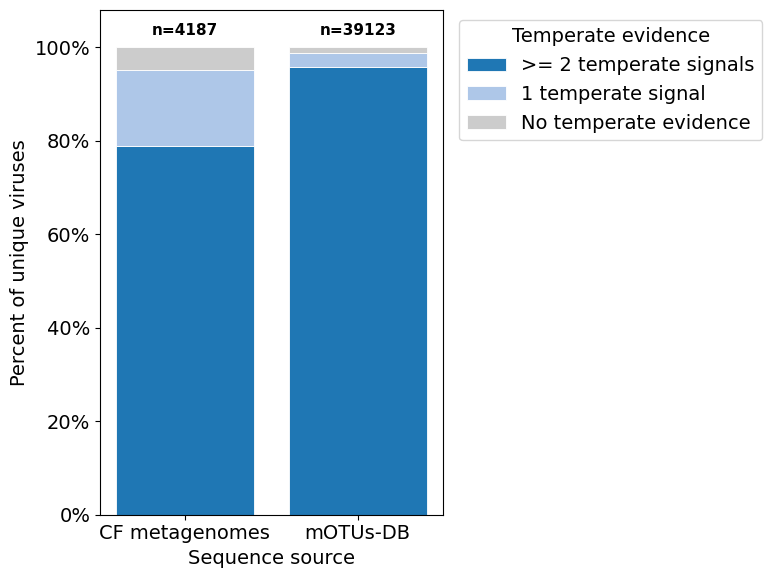

In [52]:
### Barchart of lifestyle
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plt.rcParams.update({'font.size': 14})

temperate_props = (
    cf_metadata
        .with_columns([
            pl.when(pl.col('seq_name').is_in(integrated_seqs))
                .then(pl.lit('integrated'))
                .when((pl.col('topology') == 'Provirus') | (pl.col('provirus') == 'Yes'))
                .then(pl.lit('integrated'))
                .otherwise(pl.lit('unintegrated'))
                .alias('integration_status')
        ])
        .with_columns([
            (
                (pl.col('integration_status') == 'integrated').fill_null(False).cast(pl.Int32)
                + (pl.col('temperate').cast(pl.Float64, strict=False) > 0.5).fill_null(False).cast(pl.Int32)
                + (
                    (pl.col('phrog_integrases').cast(pl.Float64, strict=False) >= 1)
                    | (pl.col('phrog_integration_excision').cast(pl.Float64, strict=False) >= 1)
                    | (pl.col('empathi_integration').cast(pl.Float64, strict=False) >= 1)
                ).fill_null(False).cast(pl.Int32)
            ).alias('temperate_signal_count')
        ])
        .with_columns(
            pl.when(pl.col('temperate_signal_count') >= 2)
                .then(pl.lit('>= 2 temperate signals'))
                .when(pl.col('temperate_signal_count') >= 1)
                .then(pl.lit('1 temperate signal'))
                .otherwise(pl.lit('No temperate evidence'))
                .alias('temperate_evidence'),
            pl.col('source_db').str.replace('CF_METAG', 'CF metagenomes').str.replace('MOTUS_DB', 'mOTUs-DB')
        )
        .group_by(['source_db', 'temperate_evidence'])
        .agg(pl.len().alias('n_unique_viruses'))
        .with_columns(
            pl.col('n_unique_viruses').sum().over('source_db').alias('source_db_total')
        )
        .with_columns(
            (pl.col('n_unique_viruses') / pl.col('source_db_total')).alias('proportion')
        )
)

temp_cat_order = (
    temperate_props
        .group_by('temperate_evidence')
        .agg(pl.col('n_unique_viruses').sum().alias('n'))
        .sort('n', descending=True)
        ['temperate_evidence']
        .to_list()
)

plot_df = (
    temperate_props
        .select(['source_db', 'temperate_evidence', 'proportion'])
        .pivot(values='proportion', index='source_db', columns='temperate_evidence')
        .fill_null(0)
        .sort('source_db')
)
source_db_order = plot_df['source_db'].to_list()
available_temperate_cats = [c for c in temp_cat_order if c in plot_df.columns]

# Get total counts per source_db
source_db_totals = (
    temperate_props
        .select('source_db', 'source_db_total')
        .unique('source_db')
        .sort('source_db')
)
totals = source_db_totals['source_db_total'].to_list()

fig, ax = plt.subplots(figsize=(8, 6))
bottom = [0.0] * len(source_db_order)
colors = plt.get_cmap('tab20').colors

for i, temperate_evidence in enumerate(available_temperate_cats):
    values = plot_df[temperate_evidence].to_list()
    # Use grey color for "No temperate evidence"
    color = '#cccccc' if temperate_evidence == 'No temperate evidence' else colors[i % len(colors)]
    ax.bar(
        source_db_order,
        values,
        bottom=bottom,
        label=temperate_evidence,
        color=color,
        edgecolor='white',
        linewidth=0.6,
    )
    bottom = [b + v for b, v in zip(bottom, values)]

# Add count labels above each source database
max_height = max(bottom)
for i, total in enumerate(totals):
    ax.text(i, max_height * 1.02, f'n={total}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Percent of unique viruses')
ax.set_xlabel('Sequence source')
ax.set_ylim(0, max_height * 1.08)
ax.legend(title='Temperate evidence', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()

In [34]:
(
    cf_metadata
        .with_columns([
            pl.when(pl.col('seq_name').is_in(integrated_seqs))
                .then(pl.lit('integrated'))
                .when((pl.col('topology') == 'Provirus') | (pl.col('provirus') == 'Yes'))
                .then(pl.lit('integrated'))
                .otherwise(pl.lit('unintegrated'))
                .alias('integration_status')
        ])
        .filter(pl.col('source_db') == 'CF_METAG')
        [['integration_status', 'temperate', 'phrog_integrases', 'phrog_integration_excision', 'empathi_integration']]
        .describe()
)

statistic,integration_status,temperate,phrog_integrases,phrog_integration_excision,empathi_integration
str,str,f64,f64,f64,f64
"""count""","""4187""",4187.0,2931.0,3277.0,3928.0
"""null_count""","""0""",0.0,1256.0,910.0,259.0
"""mean""",null,0.706511,1.214944,1.684162,3.471232
"""std""",null,0.382085,0.457246,0.853082,2.425081
"""min""","""integrated""",0.0,1.0,1.0,1.0
"""25%""",null,0.245283,1.0,1.0,2.0
"""50%""",null,0.9625,1.0,2.0,3.0
"""75%""",null,1.0,1.0,2.0,4.0
"""max""","""unintegrated""",1.0,5.0,11.0,29.0


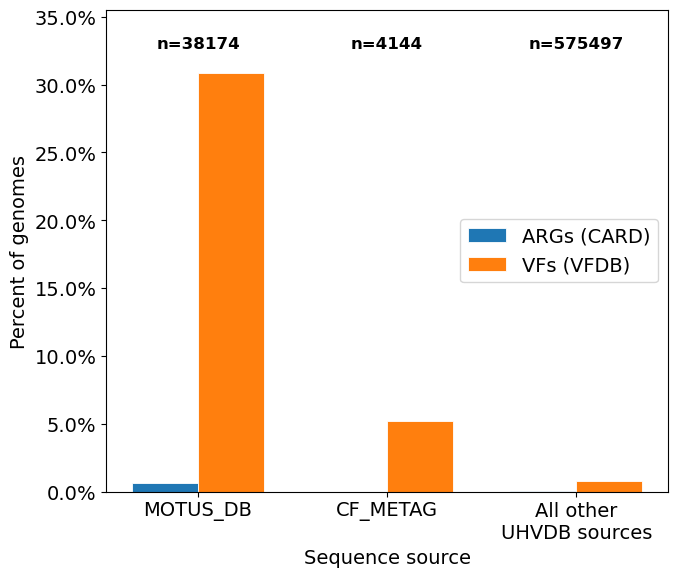

In [47]:
### Bar chart of ARGs and VFs by source database
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plt.rcParams.update({'font.size': 14})

arg_vf_props = (
    uhvdb_metadata
        .unique('hash')
        .with_columns(
            pl.when(pl.col('source_db') == 'CF_METAG').then(pl.lit('CF_METAG'))
                .when(pl.col('source_db') == 'MOTUS_DB').then(pl.lit('MOTUS_DB'))
                .otherwise(pl.lit('All other\nUHVDB sources'))
                .alias('source_db_group'),
            (pl.col('num_card') > 0).fill_null(False).alias('has_args'),
            (pl.col('num_vfdb') > 0).fill_null(False).alias('has_vfs')
        )
        .group_by('source_db_group')
        .agg([
            pl.len().alias('total'),
            pl.col('has_args').sum().alias('with_args'),
            pl.col('has_vfs').sum().alias('with_vfs')
        ])
        .with_columns([
            (pl.col('with_args') / pl.col('total')).alias('args_proportion'),
            (pl.col('with_vfs') / pl.col('total')).alias('vfs_proportion')
        ])
        .sort('source_db_group', descending=True)
)

# Create grouped bar chart
source_dbs = arg_vf_props['source_db_group'].to_list()
args_props = arg_vf_props['args_proportion'].to_list()
vfs_props = arg_vf_props['vfs_proportion'].to_list()
totals = arg_vf_props['total'].to_list()

x = range(len(source_dbs))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 6))
bars1 = ax.bar([i - width/2 for i in x], args_props, width, label='ARGs (CARD)', color='#1f77b4', edgecolor='white', linewidth=0.6)
bars2 = ax.bar([i + width/2 for i in x], vfs_props, width, label='VFs (VFDB)', color='#ff7f0e', edgecolor='white', linewidth=0.6)

# Add count labels above each source database
max_height = max(max(args_props), max(vfs_props))
for i, total in enumerate(totals):
    ax.text(i, max_height * 1.05, f'n={total}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Percent of genomes')
ax.set_xlabel('Sequence source')
ax.set_xticks(x)
ax.set_xticklabels(source_dbs)
ax.set_ylim(0, max_height * 1.15)
ax.legend()
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
plt.tight_layout()
plt.show()